# Initial Setup

This notebook contains the initial setup of the environment and download of required datasets for training, evaluation, and visualization.

Before we can start, we need to install the required dependencies for this project. This project depends on the following libraries:

- **pandas**, **numpy** & **einops**: Tabular data manipulation and numerical operations.
- **scipy**: Fundamental algorithms for scientific computing in Python.
- **pillow**: Library for loading and manipulating images.
- **opencv-python** & **opencv-contrib-python**: Computer vision library for image processing.
- **torch** & **torchvision**: A library for deep learning in Python.
- **ultralytics**: Library for use of YOLO models.
- **matplotlib**, **seaborn** & **pyvista** : Plotting libraries for data visualization.
- **jupyter** & **ipywidgets**: For displaying widgets in the notebook.
- **gdown**: Tool for downloading data from Google Drive.
- **tabulate**: Tool for converting pandas dataframes into Markdown tables. Used for formatting evaluation results.
- **kornia**: A computer vision library with implementations of some deep learning based methods. Used only for the demos.
- **networkx**: Library for crating and manipulating graphs. Used only for the demos.
- **MoGe**: A monocular depth estimation model. Used only for the demos.

In [ ]:
%%capture
%pip install numpy pandas scipy pillow opencv-python opencv-contrib-python torch torchvision
%pip install ultralytics==8.4.51 matplotlib seaborn pyvista[jupyter] jupyter ipywidgets gdown
%pip install einops tabulate kornia networkx git+https://github.com/microsoft/MoGe.git

In [ ]:
import os
import sys

from IPython.display import Video
import matplotlib.pyplot as plt

In [ ]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import dataset
import visualize

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(dataset)
importlib.reload(visualize);

First we download a dataset that is used only for the qualitative analysis and the demos. The SALSA dataset, available [here](https://tev.fbk.eu/resources/salsa), does not contain ground truth annotations so it can not be used for training.

In [ ]:
dataset.SalsaDataset().download()

We can then download the dataset from the official CMU Panoptic Dataset website. It is available at [here](http://domedb.perception.cs.cmu.edu/). Note that there is also an official download script, but this project uses some custom class to download all the relevant data.

The code to actually download the dataset can be found in the `dataset.py` python module.

In [3]:
data = dataset.CmuPanopticDataset(path="../data/panoptic")

In [6]:
# Warning: Running this will take a long time and take up a lot of disk space.
data.download(num_vga_cams=8)

# Comment the above and run only the following to only download the files used for
# evaluation of the complete system (a subset of sequences not used during training).
data.download(num_vga_cams=16, scenes=dataset.CmuPanopticDataset.test_scenes)

Let us load one of the videos in the dataset to verify that we downloaded it correctly.

In [4]:
Video(filename="../data/panoptic/160224_haggling1/vga_06_15.mp4")

Now that we have the raw dataset, we can preprocess it into a format useful for training the custom YOLO based model as well as for learning the Kalman parameters. This is also implemented on the `CmuPanopticDataset` class in `dataset.py`.

The YOLO dataset is generated by talking frames every second of the video from a random camera out of the ones that we loaded. Only if at least one person annotation exists and is visible in the frame will a sample be created. This dataset is used for training a custom output head for the YOLO model that predicts the uncertainty of the prediction.

The Kalman dataset is generated by extracting individual tracks from the ground truth annotations. This dataset is used to learn the parameters for the Kalman filter physics from the data. This is implemented by performing backpropagation through time on short sequences extracted from the individual tracks.

In [ ]:
# The generation of the YOLO dataset is randomized. Therefore we set the seed to
# get a reproducible dataset.
util.set_seed(42)

# Warning: Again, running this will take quite a long time. Therefore the below
# code will only execute if the folder does not yet exist. Delete the folder to
# recreate the dataset,
if not os.path.exists("../data/yolo"):
    data.extract_yolo_dataset(path="../data/yolo")
if not os.path.exists("../data/kalman"):
    data.extract_kalman_dataset(path="../data/kalman")
if not os.path.exists("../data/tune"):
    data.extract_tune_dataset(path="../data/tune")

Finally, let's make use we successfully downloaded and extracted the dataset by loading some samples from it. First, let us load an image from the YOLO dataset.

Number of training samples: 17216
Number of validation samples: 3160


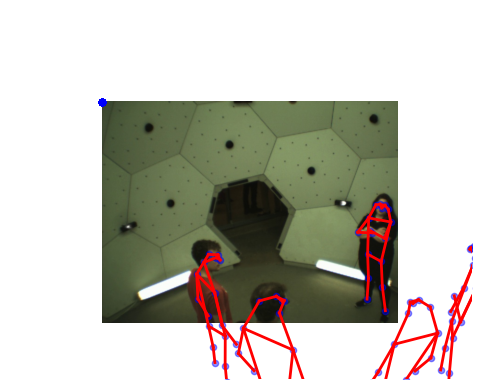

In [14]:
data = dataset.YoloDataset("../data/yolo/train")
data_val = dataset.YoloDataset("../data/yolo/val")

print("Number of training samples:", len(data))
print("Number of validation samples:", len(data_val))

img, ann = data[1234]
for kp in ann:
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')
plt.imshow(img.permute(1, 2, 0))
plt.xlim(-200, 800)
plt.ylim(600, -200)
plt.axis("off")
plt.show()

Then let us load also a track from the dataset intended to train the Kalman filter.

In [3]:
data = dataset.KalmanDataset("../data/kalman/train")
data_val = dataset.KalmanDataset("../data/kalman/val")

print("Number of training samples:", len(data))
print("Number of validation samples:", len(data_val))

fps, track = data[1000]
print(f"FPS: {fps.item():.2f}")
visualize.MinimalSkeletonPlayer(track, fps.item()).show()

Number of training samples: 35967
Number of validation samples: 6684
FPS: 29.97


Widget(value='<iframe src="http://localhost:33185/index.html?ui=P_0x7f1040577b60_0&reconnect=auto" class="pyvi…